# FinBERT Example Notebook

This notebooks shows how to train and use the FinBERT pre-trained language model for financial sentiment analysis.

## Modules 

In [1]:
# Note: Triton is an optional PyTorch dependency for optimized GPU kernels
# It's only available on Linux and not required for FinBERT training
# If you're on Linux and want to install it, uncomment the line below:
# !pip install triton

In [2]:
from pathlib import Path
import shutil
import os
import logging
import sys
sys.path.append('..')

from textblob import TextBlob
from pprint import pprint
from sklearn.metrics import classification_report, balanced_accuracy_score

from transformers import AutoModelForSequenceClassification

from finbert.finbert import *
import finbert.utils as tools

%load_ext autoreload
%autoreload 2

project_dir = Path.cwd().parent
pd.set_option('max_colwidth', None)

In [3]:
logging.basicConfig(format = '%(asctime)s - %(levelname)s - %(name)s -   %(message)s',
                    datefmt = '%m/%d/%Y %H:%M:%S',
                    level = logging.ERROR)

## Prepare the model

### Setting path variables:
1. `lm_path`: the path for the pre-trained language model (If vanilla Bert is used then no need to set this one).
2. `cl_path`: the path where the classification model is saved.
3. `cl_data_path`: the path of the directory that contains the data files of `train.csv`, `validation.csv`, `test.csv`.
---

In the initialization of `bertmodel`, we can either use the original pre-trained weights from Google by giving `bm = 'bert-base-uncased`, or our further pre-trained language model by `bm = lm_path`


---
All of the configurations with the model is controlled with the `config` variable. 

In [4]:
# Note: Triton is an optional PyTorch dependency for optimized GPU kernels
# It's only available on Linux and not required for FinBERT training
# If you're on Linux and want to install it, uncomment the line below:
# !pip install triton

In [5]:
import requests
import os
import shutil
from pathlib import Path
from tqdm import tqdm

# Download FinBERT language model
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
model_dir = project_root / 'models' / 'language_model' / 'finbertTRC2'
model_dir.mkdir(parents=True, exist_ok=True)

url = 'https://prosus-public.s3-eu-west-1.amazonaws.com/finbert/language-model/pytorch_model.bin'
dest_path = model_dir / 'pytorch_model.bin'

if not dest_path.exists():
    response = requests.get(url, stream=True)
    response.raise_for_status()
    total_size = int(response.headers.get('content-length', 0))
    with open(dest_path, 'wb') as f:
        with tqdm(total=total_size, unit='B', unit_scale=True, desc='Downloading') as pbar:
            for chunk in response.iter_content(chunk_size=8192):
                if chunk:
                    f.write(chunk)
                    pbar.update(len(chunk))

# Copy config.json if it exists
config_source = project_root / 'config.json'
config_dest = model_dir / 'config.json'
if config_source.exists() and not config_dest.exists():
    shutil.copy2(str(config_source), str(config_dest))

In [56]:
lm_path = project_dir / "models" / "language_model" / "finbertTRC2"
cl_path = project_dir / "models" / "classifier_model" / "finbert-sentiment"
# cl_data_path = "NOSIBLE/financial-sentiment"
# cl_data_path = project_dir / "data" / "sentiment_data"
cl_data_path = "zeroshot/twitter-financial-news-sentiment"

###  Configuring training parameters

You can find the explanations of the training parameters in the class docsctrings. 

In [57]:
# Clean the cl_path
try:
    shutil.rmtree(cl_path)
except:
    pass

# Load model with fallback to bert-base-uncased if local model not found
try:
    bertmodel = AutoModelForSequenceClassification.from_pretrained(
        str(lm_path), cache_dir=None, num_labels=3, local_files_only=True)
except:
    print("Local model not found, using bert-base-uncased as fallback")
    bertmodel = AutoModelForSequenceClassification.from_pretrained('google-bert/bert-base-uncased', num_labels=3)

config = Config(data_dir=cl_data_path,
                bert_model=bertmodel,
                num_train_epochs=10,
                model_dir=cl_path,
                max_seq_length=128,
                train_batch_size=32,
                learning_rate=2e-5,
                output_mode='classification',
                warm_up_proportion=0.2,
                local_rank=-1,
                discriminate=True,
                gradual_unfreeze=True)

Some weights of BertForSequenceClassification were not initialized from the model checkpoint at /Users/bruno/ws/finBERT/models/language_model/finbertTRC2 and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


`finbert` is our main class that encapsulates all the functionality. The list of class labels should be given in the prepare_model method call with label_list parameter.

In [58]:
finbert = FinBert(config)
finbert.base_model = 'bert-base-uncased'
finbert.config.discriminate=True
finbert.config.gradual_unfreeze=True

In [59]:
finbert.prepare_model(label_list=['positive','negative','neutral'])

12/24/2025 18:05:40 - INFO - finbert.finbert -   device: mps n_gpu: 1, distributed training: False, 16-bits training: False


## Fine-tune the model

In [60]:
# Get the training examples
train_data = finbert.get_data('train')

12/24/2025 18:05:44 - INFO - finbert.utils -   Dataset columns: ['text', 'label']
12/24/2025 18:05:44 - INFO - finbert.utils -   Loaded 9543 examples from Hugging Face dataset 'zeroshot/twitter-financial-news-sentiment' (split: train)
12/24/2025 18:05:45 - INFO - finbert.finbert -   Unique labels found in dataset: ['0', '1', '2']
12/24/2025 18:05:45 - INFO - finbert.finbert -   Expected labels: ['positive', 'negative', 'neutral']
12/24/2025 18:05:45 - INFO - finbert.finbert -   Label mapping: {'0': {'count': 1442, 'normalized_to': 'negative'}, '1': {'count': 1923, 'normalized_to': 'positive'}, '2': {'count': 6178, 'normalized_to': 'neutral'}}
12/24/2025 18:05:45 - INFO - finbert.finbert -   Normalized label distribution: {'neutral': 6178, 'positive': 1923, 'negative': 1442}
12/24/2025 18:05:45 - INFO - finbert.finbert -   Label 'positive': 1923 samples, weight: 4.9626
12/24/2025 18:05:45 - INFO - finbert.finbert -   Label 'negative': 1442 samples, weight: 6.6179
12/24/2025 18:05:45 - I

In [61]:
model = finbert.create_the_model()

### [Optional] Fine-tune only a subset of the model
The variable `freeze` determines the last layer (out of 12) to be freezed. You can skip this part if you want to fine-tune the whole model.

<span style="color:red">Important: </span>
Execute this step if you want a shorter training time in the expense of accuracy.

In [62]:
# This is for fine-tuning a subset of the model.

freeze = 6

base_model = None
# Detect model architecture (BERT vs RoBERTa)
if hasattr(model, 'bert'):
    base_model = model.bert
    model_type = 'bert'
elif hasattr(model, 'roberta'):
    base_model = model.roberta
    model_type = 'roberta'

for param in base_model.embeddings.parameters():
    param.requires_grad = False
    
for i in range(freeze):
    for param in base_model.encoder.layer[i].parameters():
        param.requires_grad = False

### Training

In [63]:
trained_model = finbert.train(train_examples=train_data, model=model)

12/24/2025 18:05:48 - INFO - finbert.utils -   Dataset columns: ['text', 'label']
12/24/2025 18:05:48 - INFO - finbert.utils -   Loaded 2388 examples from Hugging Face dataset 'zeroshot/twitter-financial-news-sentiment' (split: validation)
12/24/2025 18:05:48 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:05:48 - INFO - finbert.utils -   guid: train-1
12/24/2025 18:05:48 - INFO - finbert.utils -   tokens: [CLS] $ by ##nd - jp ##mo ##rgan reel ##s in expectations on beyond meat [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD

Iteration:   0%|          | 0/299 [00:00<?, ?it/s]

12/24/2025 18:06:30 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:06:30 - INFO - finbert.utils -   guid: validation-1
12/24/2025 18:06:30 - INFO - finbert.utils -   tokens: [CLS] $ ally - ally financial pulls outlook [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
12/24/2025 18:06:30 - INFO - finbert.utils -   input

Validating:   0%|          | 0/75 [00:00<?, ?it/s]

Validation losses: [1.036649550596873]
No best model found


...

Iteration:   0%|          | 0/299 [00:00<?, ?it/s]

12/24/2025 18:22:44 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:22:44 - INFO - finbert.utils -   guid: validation-1
12/24/2025 18:22:44 - INFO - finbert.utils -   tokens: [CLS] $ ally - ally financial pulls outlook [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
12/24/2025 18:22:44 - INFO - finbert.utils -   input

Validating:   0%|          | 0/75 [00:00<?, ?it/s]

Epoch: 100%|██████████| 10/10 [17:03<00:00, 102.35s/it]

Validation losses: [1.036649550596873, 0.5369854138294856, 0.47984469229976334, 0.43262695928414663, 0.45916377534468966, 0.37919104351351657, 0.39938736394047736, 0.4089801067362229, 0.4271208658255637, 0.41274400414898993]


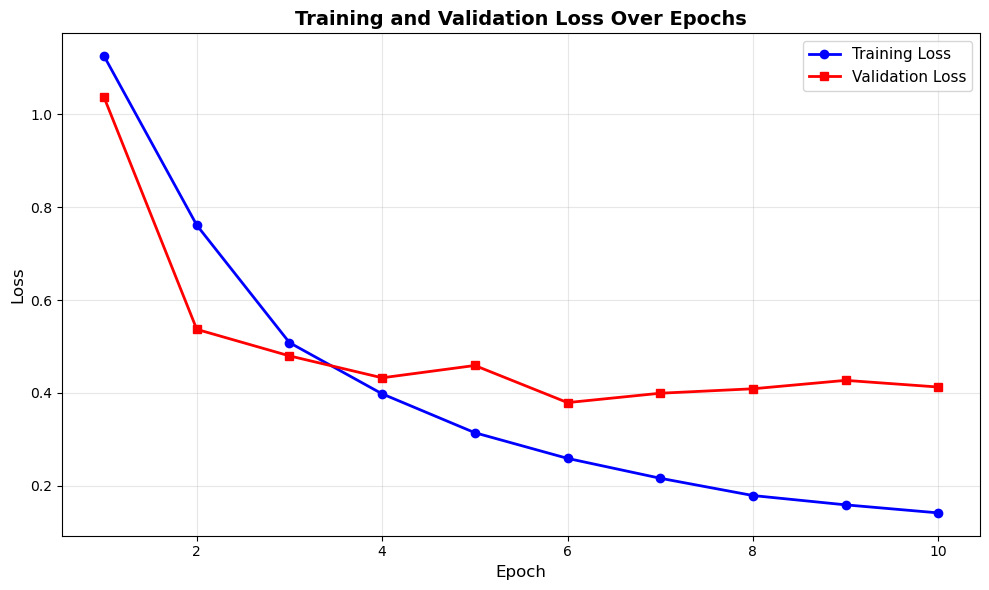

Training losses: [1.1256480452209012, 0.7613869621402842, 0.5083564887676749, 0.39800616226666746, 0.3142936320408531, 0.25899365333759267, 0.21620151181907757, 0.17894528571977264, 0.15888227884934897, 0.14156409014128524]
Validation losses: [1.036649550596873, 0.5369854138294856, 0.47984469229976334, 0.43262695928414663, 0.45916377534468966, 0.37919104351351657, 0.39938736394047736, 0.4089801067362229, 0.4271208658255637, 0.41274400414898993]

Best validation loss: 0.3792 at epoch 6


In [64]:
# plot the training loss
import matplotlib.pyplot as plt
import numpy as np

epochs = range(1, len(finbert.training_losses) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, finbert.training_losses, 'b-o', label='Training Loss', linewidth=2, markersize=6)
plt.plot(epochs, finbert.validation_losses, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss Over Epochs', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Training losses: {finbert.training_losses}")
print(f"Validation losses: {finbert.validation_losses}")
print(f"\nBest validation loss: {min(finbert.validation_losses):.4f} at epoch {np.argmin(finbert.validation_losses) + 1}")

## Test the model

`bert.evaluate` outputs the DataFrame, where true labels and logit values for each example is given

In [65]:
test_data = finbert.get_data('test')

12/24/2025 18:22:57 - INFO - finbert.utils -   Available splits: ['train', 'validation']
12/24/2025 18:22:57 - WARNING - finbert.utils -   Split 'test' not found. Using 'train' instead.
12/24/2025 18:22:57 - INFO - finbert.utils -   Dataset columns: ['text', 'label']
12/24/2025 18:22:57 - INFO - finbert.utils -   Loaded 9543 examples from Hugging Face dataset 'zeroshot/twitter-financial-news-sentiment' (split: test)


In [66]:
results = finbert.evaluate(examples=test_data, model=trained_model)

12/24/2025 18:22:57 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:22:57 - INFO - finbert.utils -   guid: test-1
12/24/2025 18:22:57 - INFO - finbert.utils -   tokens: [CLS] $ by ##nd - jp ##mo ##rgan reel ##s in expectations on beyond meat [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
12/24/2025 18:22:57 - INFO - finbert.utils -   input_ids: 101 1002 2011

Testing:   0%|          | 0/299 [00:00<?, ?it/s]

### Prepare the classification report

In [67]:
def report(df, cols=['label','prediction','logits']):
    df_valid = df[df[cols[0]] != 9090].copy()
    
    if len(df_valid) > 0:
        loss = CrossEntropyLoss(weight=finbert.class_weights)(
            torch.tensor(list(df_valid[cols[2]])),
            torch.tensor(list(df_valid[cols[0]]))
        )
        accuracy = (df_valid[cols[0]] == df_valid[cols[1]]).mean()
        balanced_acc = balanced_accuracy_score(df_valid[cols[0]], df_valid[cols[1]])
        print(f"Loss: {loss:.5f}")
        print(f"Accuracy: {accuracy:.5f}")
        print(f"Balanced Accuracy: {balanced_acc:.5f}")
        print("\nClassification Report (with labels):")
        print(classification_report(df_valid[cols[0]], df_valid[cols[1]]))
    else:
        print("No ground truth labels available. Showing predictions only.")
    
    label_names = ['positive', 'negative', 'neutral']
    print("\nPrediction Distribution:")
    for idx, count in df[cols[1]].value_counts().sort_index().items():
        name = label_names[int(idx)] if int(idx) < len(label_names) else f'class_{idx}'
        print(f'  {name}: {count} ({count/len(df)*100:.1f}%)')


In [68]:
results['prediction'] = results.predictions.apply(lambda x: np.argmax(x,axis=0))

In [69]:
report(results,cols=['labels','prediction','predictions'])

Loss: 0.15687
Accuracy: 0.94551
Balanced Accuracy: 0.95361

Classification Report (with labels):
              precision    recall  f1-score   support

           0       0.89      0.97      0.93      1923
           1       0.87      0.96      0.91      1442
           2       0.99      0.94      0.96      6178

    accuracy                           0.95      9543
   macro avg       0.92      0.95      0.93      9543
weighted avg       0.95      0.95      0.95      9543


Prediction Distribution:
  positive: 2090 (21.9%)
  negative: 1585 (16.6%)
  neutral: 5868 (61.5%)


### Evaluate on Validation Set (with labels)

Evaluate the model on validation data which has ground truth labels to get metrics.

In [70]:
# Get validation data (which has labels)
validation_data = finbert.get_data("validation")

# Evaluate on validation set
val_results = finbert.evaluate(examples=validation_data, model=trained_model)
val_results["prediction"] = val_results.predictions.apply(lambda x: np.argmax(x,axis=0))

# Generate full report with metrics
report(val_results, cols=["labels","prediction","predictions"])

12/24/2025 18:23:29 - INFO - finbert.utils -   Dataset columns: ['text', 'label']
12/24/2025 18:23:29 - INFO - finbert.utils -   Loaded 2388 examples from Hugging Face dataset 'zeroshot/twitter-financial-news-sentiment' (split: validation)
12/24/2025 18:23:29 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:23:29 - INFO - finbert.utils -   guid: validation-1
12/24/2025 18:23:29 - INFO - finbert.utils -   tokens: [CLS] $ ally - ally financial pulls outlook [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD

Testing:   0%|          | 0/75 [00:00<?, ?it/s]

Loss: 0.43071
Accuracy: 0.87144
Balanced Accuracy: 0.84639

Classification Report (with labels):
              precision    recall  f1-score   support

           0       0.79      0.84      0.82       475
           1       0.75      0.80      0.78       347
           2       0.93      0.90      0.91      1566

    accuracy                           0.87      2388
   macro avg       0.82      0.85      0.83      2388
weighted avg       0.87      0.87      0.87      2388


Prediction Distribution:
  positive: 505 (21.1%)
  negative: 370 (15.5%)
  neutral: 1513 (63.4%)


### Get predictions

With the `predict` function, given a piece of text, we split it into a list of sentences and then predict sentiment for each sentence. The output is written into a dataframe. Predictions are represented in three different columns: 

1) `logit`: probabilities for each class

2) `prediction`: predicted label

3) `sentiment_score`: sentiment score calculated as: probability of positive - probability of negative

Below we analyze a paragraph taken out of [this](https://www.economist.com/finance-and-economics/2019/01/03/a-profit-warning-from-apple-jolts-markets) article from The Economist. For comparison purposes, we also put the sentiments predicted with TextBlob.
> Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened. The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. Yields on government bonds fell as investors fled to the traditional haven in a market storm.

In [71]:
text = "Later that day Apple said it was revising down its earnings expectations in \
the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China. \
The news rapidly infected financial markets. Apple’s share price fell by around 7% in after-hours \
trading and the decline was extended to more than 10% when the market opened. The dollar fell \
by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering \
some ground. Asian stockmarkets closed down on January 3rd and European ones opened lower. \
Yields on government bonds fell as investors fled to the traditional haven in a market storm."

In [72]:
cl_path = project_dir/'models'/'classifier_model'/'finbert-sentiment'
cl_path_str = os.path.abspath(str(cl_path))

# Check if the model path exists
if not os.path.exists(cl_path_str):
    raise FileNotFoundError(f"Classifier model path does not exist: {cl_path_str}. Please train the model first or ensure the path is correct.")
else:
    model = AutoModelForSequenceClassification.from_pretrained(cl_path_str, cache_dir=None, num_labels=3, local_files_only=True)

In [73]:
import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/bruno/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [74]:
result = predict(text,model)

12/24/2025 18:23:38 - INFO - root -   Using device: cpu 
12/24/2025 18:23:38 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:23:38 - INFO - finbert.utils -   guid: 0
12/24/2025 18:23:38 - INFO - finbert.utils -   tokens: [CLS] later that day apple said it was rev ##ising down its earnings expectations in the fourth quarter of 2018 , largely because of lower sales and signs of economic weakness in china . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
12/24/2025 18:23:38 - INFO - finbert.utils -   input_ids: 101 2101 2008 2154 6207 2056 2009 2001 7065 9355 2091 2049 16565 10908 1999 1996 2959 4284 1997 2760 1010 4321 2138 1997 2896 4341 1998 5751 1997 3171 11251 1999 2859 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2025 18:23:38 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 

In [75]:
blob = TextBlob(text)
result['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]
result

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,"Later that day Apple said it was revising down its earnings expectations in the fourth quarter of 2018, largely because of lower sales and signs of economic weakness in China.","[0.019500757, 0.96165633, 0.018842883]",negative,-0.942156,0.051746
1,The news rapidly infected financial markets.,"[0.016574092, 0.89876056, 0.084665254]",negative,-0.882186,0.000000
2,Apple’s share price fell by around 7% in after-hours trading and the decline was extended to more than 10% when the market opened.,"[0.00564908, 0.98352826, 0.010822598]",negative,-0.977879,0.500000
3,"The dollar fell by 3.7% against the yen in a matter of minutes after the announcement, before rapidly recovering some ground.","[0.01754924, 0.96844786, 0.014002906]",negative,-0.950899,0.000000
4,Asian stockmarkets closed down on January 3rd and European ones opened lower.,"[0.005524746, 0.9826554, 0.01181982]",negative,-0.977131,-0.051111
5,Yields on government bonds fell as investors fled to the traditional haven in a market storm.,"[0.011214203, 0.94354385, 0.045241896]",negative,-0.932330,0.000000


In [76]:
print(f'Average sentiment is %.5f.' % (result.sentiment_score.mean()))

Average sentiment is -0.94376.


Here is another example

In [77]:
text2 = "Shares in the spin-off of South African e-commerce group Naspers surged more than 25% \
in the first minutes of their market debut in Amsterdam on Wednesday. Bob van Dijk, CEO of \
Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the \
Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019. REUTERS/Piroschka van de Wouw \
Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a \
31% stake in Chinese tech titan Tencent. There is 'way more demand than is even available, so that’s \
good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg. 'It’s going to be an interesting \
hour of trade after opening this morning.' Euronext had given an indicative price of 58.70 euros \
per share for Prosus, implying a market value of 95.3 billion euros ($105 billion). The shares \
jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT."

In [78]:
result2 = predict(text2,model)
blob = TextBlob(text2)
result2['textblob_prediction'] = [sentence.sentiment.polarity for sentence in blob.sentences]

12/24/2025 18:23:38 - INFO - root -   Using device: cpu 
12/24/2025 18:23:38 - INFO - finbert.utils -   *** Example ***
12/24/2025 18:23:38 - INFO - finbert.utils -   guid: 0
12/24/2025 18:23:38 - INFO - finbert.utils -   tokens: [CLS] shares in the spin - off of south african e - commerce group nas ##pers surged more than 25 % in the first minutes of their market debut in amsterdam on wednesday . [SEP] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD] [PAD]
12/24/2025 18:23:38 - INFO - finbert.utils -   input_ids: 101 6661 1999 1996 6714 1011 2125 1997 2148 3060 1041 1011 6236 2177 17235 7347 18852 2062 2084 2423 1003 1999 1996 2034 2781 1997 2037 3006 2834 1999 7598 2006 9317 1012 102 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
12/24/2025 18:23:38 - INFO - finbert.utils -   attention_mask: 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1

In [79]:
result2

,sentence,logit,prediction,sentiment_score,textblob_prediction
0,Shares in the spin-off of South African e-commerce group Naspers surged more than 25% in the first minutes of their market debut in Amsterdam on Wednesday.,"[0.9736969, 0.005963999, 0.020339077]",positive,0.967733,0.250000
1,"Bob van Dijk, CEO of Naspers and Prosus Group poses at Amsterdam's stock exchange, as Prosus begins trading on the Euronext stock exchange in Amsterdam, Netherlands, September 11, 2019.","[0.009801972, 0.005917093, 0.98428094]",neutral,0.003885,0.000000
2,"REUTERS/Piroschka van de Wouw Prosus comprises Naspers’ global empire of consumer internet assets, with the jewel in the crown a 31% stake in Chinese tech titan Tencent.","[0.028855283, 0.004527532, 0.9666171]",neutral,0.024328,0.000000
3,"There is 'way more demand than is even available, so that’s good,' said the CEO of Euronext Amsterdam, Maurice van Tilburg.","[0.85151446, 0.04635422, 0.10213124]",positive,0.805160,0.533333
4,'It’s going to be an interesting hour of trade after opening this morning.',"[0.4571919, 0.007965065, 0.5348431]",neutral,0.449227,0.500000
5,"Euronext had given an indicative price of 58.70 euros per share for Prosus, implying a market value of 95.3 billion euros ($105 billion).","[0.2711915, 0.026733354, 0.70207506]",neutral,0.244458,0.000000
6,The shares jumped to 76 euros on opening and were trading at 75 euros at 0719 GMT.,"[0.8371747, 0.0072553004, 0.15556999]",positive,0.829919,0.000000


In [80]:
print(f'Average sentiment is %.5f.' % (result2.sentiment_score.mean()))

Average sentiment is 0.47496.
